# 📚 Section 4. Comparison Chart — Bar (4 Types: Vertical / Horizontal / Grouped / Stacked)
> 섹션 4. 비교 차트 — Bar 4종 (세로 / 가로 / 그룹 / 누적)

---
# 🎯 Learning Objective · 학습 목표
Today I want to learn: · 오늘 배우고 싶은 것:
- [x] Know all 4 Bar Chart variants (vertical, horizontal, grouped, stacked) and when to reach for each one  
Bar Chart의 4가지 변형(세로, 가로, 그룹, 누적)을 알고 각각 언제 써야 하는지 파악하기
- [x] Build a Grouped Bar chart using numpy offsets, and understand the width × group-count rule  
numpy 오프셋으로 그룹 막대를 만들고, width × 그룹 수 규칙을 이해하기
- [x] Build a Stacked Bar chart using the bottom= parameter, including 3+ layer stacks  
bottom= 파라미터로 누적 막대를 만들고, 3단 이상 누적까지 다루기

---
# 🧠 Concept · 개념

## What is it? · 무엇인가?

A Bar Chart represents the size of categorical data as the length of a bar, comparing values across items. It's the single most-used chart type in DA/BA work.

Bar Chart(막대 그래프)는 범주형 데이터의 크기를 막대의 길이로 표현하여 항목 간 크기를 비교하는 차트입니다. DA/BA 실무에서 가장 많이 사용되는 차트 유형입니다.

## Why do we use it? · 왜 사용하는가?

Use it whenever the question is "which item is the biggest/smallest?" There are 4 variants, and which one you pick depends on your specific goal.

"어떤 항목이 가장 큰가/작은가"를 비교하고 싶을 때 사용합니다. 목적에 따라 4가지 변형 중 하나를 선택합니다.

DA/BA situations: product/branch sales comparison, survey response distribution, headcount by department, channel contribution comparison.

DA/BA 실무 상황: 제품별·지점별 매출 비교, 설문 응답 분포, 부서별 인원 수, 채널별 기여도 비교 등.

## When is it used in Business Analytics? · 언제 비즈니스 분석에서 사용되는가?

One axis holds categorical data that doesn't need to be ordered (product name, region name, department name); the other axis holds a numeric value. Which of the 4 variants fits depends on the exact question:

한 축은 순서가 없어도 되는 범주형 데이터(제품명, 지역명, 부서명 등), 다른 한 축은 수치형 데이터입니다. 정확히 어떤 질문이냐에 따라 4가지 변형 중 하나를 고릅니다:

| Variant / 유형 | Code / 코드 | Use when / 언제 사용 | Example / 예시 |
|---|---|---|---|
| Vertical / 세로 | `ax.bar()` | Few categories (~7 or fewer), a general comparison / 카테고리가 적고(~7개 이하) 일반적인 비교 | Sales by product / 제품별 매출 |
| Horizontal / 가로 | `ax.barh()` | Long category names or 8+ categories / 카테고리 이름이 길거나 개수가 많을 때(8개 이상) | Country ranking / 국가별 순위 |
| Grouped / 그룹 | `ax.bar(x±offset, width)` | Comparing 2-3 subgroups side by side per category / 카테고리별로 2~3개 하위 그룹을 나란히 비교 | H1 vs H2 sales by region / 지역별 상/하반기 매출 |
| Stacked / 누적 | `ax.bar(bottom=)` | Showing the total and its composition at once / 합계와 구성 비율을 동시에 보고 싶을 때 | Sales composition by channel / 채널별 매출 구성 |

---
# 📝 Syntax · 문법

## Basic Syntax · 기본 문법

`ax.bar(categories, values)` is the standard vertical bar chart — the go-to when you have a small number of short category names.

`ax.bar(카테고리, 값)`은 표준 세로 막대 차트입니다 — 카테고리 개수가 적고 이름이 짧을 때 기본으로 씁니다.

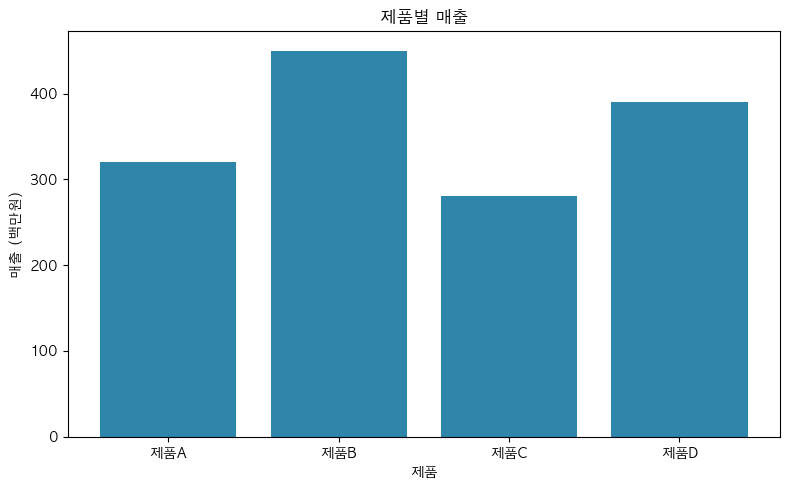

In [1]:
# Basic Syntax: vertical bar chart
# 기본 문법: 세로 막대 차트

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'   # macOS: 'AppleGothic', Windows: 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

products = ['제품A', '제품B', '제품C', '제품D']
sales = [320, 450, 280, 390]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(products, sales, color='#2E86AB')
ax.set_title('제품별 매출')
ax.set_xlabel('제품')
ax.set_ylabel('매출 (백만원)')
plt.tight_layout()
plt.show()

## Common Variations · 주요 변형

Swap `ax.bar()` for `ax.barh()` and the same data becomes a horizontal bar chart — the axes simply rotate 90°. Reach for this whenever category names are long or there are 8+ categories, since the names get room to breathe along the y-axis instead of colliding on the x-axis.

`ax.bar()`를 `ax.barh()`로 바꾸면 같은 데이터가 가로 막대 차트가 됩니다 — 축이 90도 회전할 뿐입니다. 카테고리 이름이 길거나 8개 이상일 때 사용하세요, x축에 라벨이 겹칠 걱정 없이 y축에 세로로 여유 있게 표시할 수 있습니다.

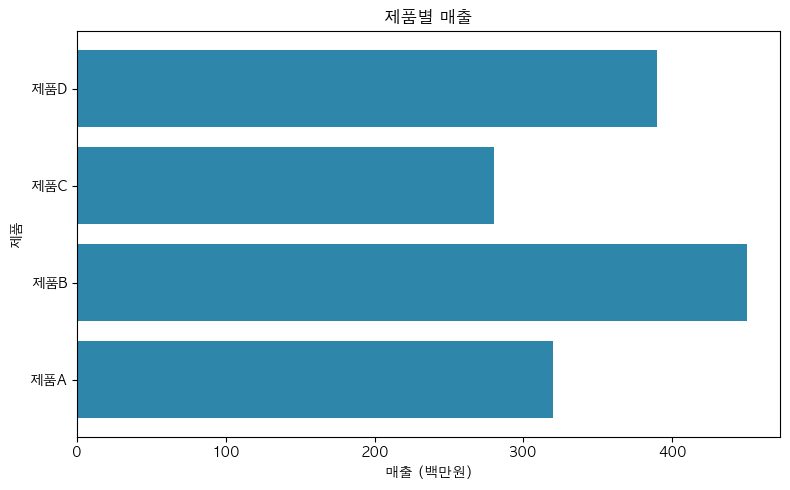

In [2]:
# Common Variations: the same data as a horizontal bar chart
# 주요 변형: 같은 데이터를 가로 막대 차트로

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

products = ['제품A', '제품B', '제품C', '제품D']
sales = [320, 450, 280, 390]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(products, sales, color='#2E86AB')
ax.set_title('제품별 매출')
ax.set_xlabel('매출 (백만원)')
ax.set_ylabel('제품')
plt.tight_layout()
plt.show()

---
# 🧪 Small Examples · 예제

## Example 1: Grouped Bar · 예제 1: 그룹 막대

Use this when you want to place 2-3 subgroups side by side within each category. The trick is shifting each group's x-position slightly with `numpy`.

카테고리별로 2~3개 하위 그룹을 나란히 배치하고 싶을 때 사용합니다. 핵심은 `numpy`로 각 그룹의 x 위치를 살짝씩 옆으로 이동시키는 것입니다.

⚙️ **The logic:** `x = np.arange(4)` gives you `[0, 1, 2, 3]`, the center position of each category. Shifting one group left by `width/2` and the other right by `width/2` places them side by side without overlapping. With 3 groups, you'd instead use `x - width`, `x`, `x + width`.

⚙️ **원리:** `x = np.arange(4)`는 `[0, 1, 2, 3]`이라는 각 카테고리의 중심 위치입니다. 한 그룹은 `width/2`만큼 왼쪽으로, 다른 그룹은 `width/2`만큼 오른쪽으로 이동시켜 겹치지 않게 나란히 배치합니다. 그룹이 3개라면 `x - width`, `x`, `x + width`처럼 위치를 3등분해야 합니다.

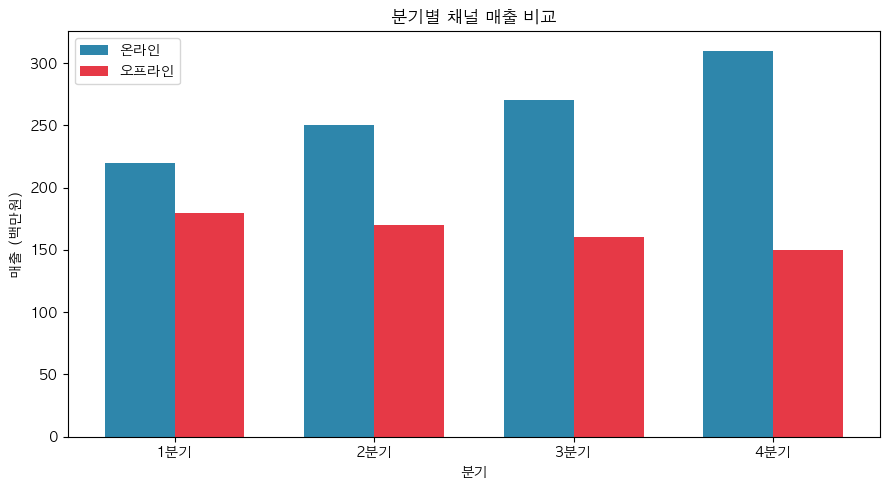

In [3]:
# Example 1: grouped bar - online vs offline sales by quarter
# 예제 1: 그룹 막대 - 분기별 온라인 vs 오프라인 매출

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

quarters = ['1분기', '2분기', '3분기', '4분기']
online = [220, 250, 270, 310]
offline = [180, 170, 160, 150]

x = np.arange(len(quarters))   # [0, 1, 2, 3]
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, online, width, label='온라인', color='#2E86AB')
ax.bar(x + width/2, offline, width, label='오프라인', color='#E63946')
ax.set_title('분기별 채널 매출 비교')
ax.set_xlabel('분기')
ax.set_ylabel('매출 (백만원)')
ax.set_xticks(x)
ax.set_xticklabels(quarters)
ax.legend()
plt.tight_layout()
plt.show()

## Example 2: Stacked Bar · 예제 2: 누적 막대

Use this when you want the total *and* its composition visible at once. The key is the `bottom=` parameter on every bar after the first one, which tells Matplotlib "start stacking from here" instead of from zero.

합계와 그 구성 비율을 동시에 보여주고 싶을 때 사용합니다. 핵심은 첫 번째를 제외한 모든 막대에 `bottom=` 파라미터를 지정해, "0이 아니라 여기서부터 쌓아라"라고 Matplotlib에 알려주는 것입니다.

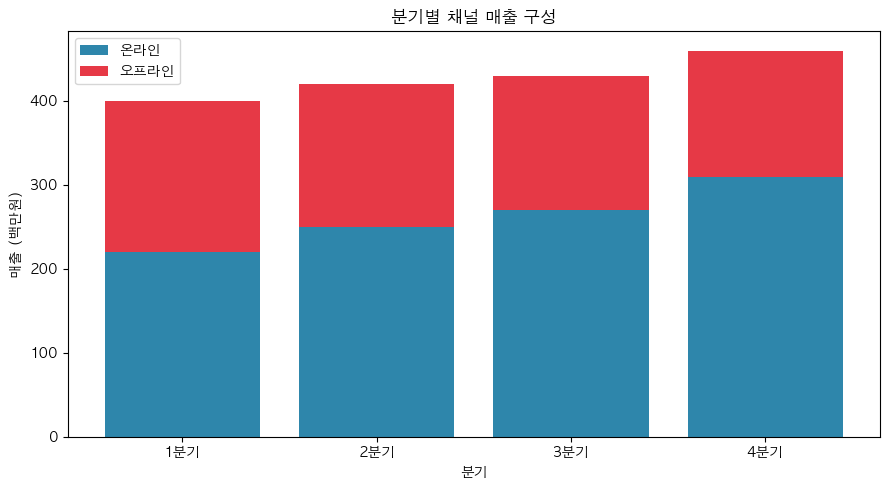

In [4]:
# Example 2: stacked bar - channel composition of quarterly sales
# 예제 2: 누적 막대 - 분기별 매출의 채널 구성

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

quarters = ['1분기', '2분기', '3분기', '4분기']
online = [220, 250, 270, 310]
offline = [180, 170, 160, 150]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(quarters, online, label='온라인', color='#2E86AB')
ax.bar(quarters, offline, bottom=online, label='오프라인', color='#E63946')
ax.set_title('분기별 채널 매출 구성')
ax.set_xlabel('분기')
ax.set_ylabel('매출 (백만원)')
ax.legend()
plt.tight_layout()
plt.show()

## Example 3: Practice · 예제 3: 연습문제

Rebuild a grouped bar chart comparing H1 vs H2 sales across 3 branches. Fill in a bar width and two colors below — it runs without error either way, and the real chart appears once every blank is filled in.

3개 지점의 상반기 vs 하반기 매출을 비교하는 그룹 막대 차트를 다시 만들어보세요. 아래에 막대 너비와 색상 2개를 채우세요 — 어떤 상태든 에러 없이 실행되며, 모든 빈칸을 채워야 실제 차트가 나타납니다.

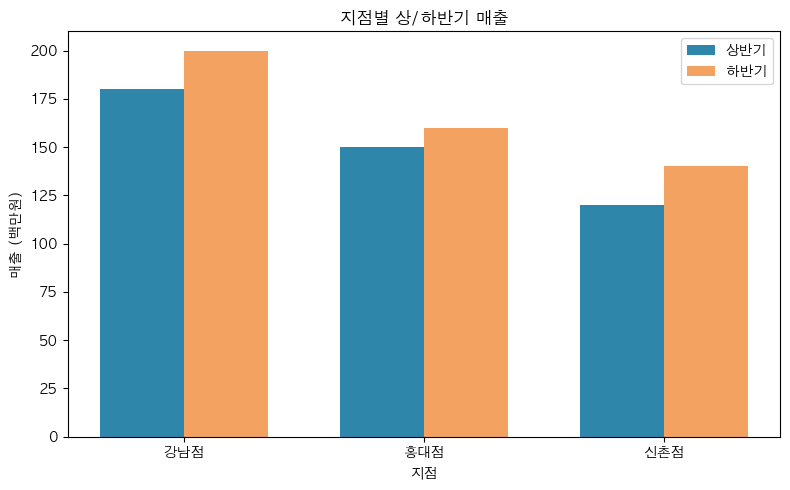

In [7]:
# Practice: fill in the blanks, then re-run this cell
# 연습문제: 빈칸을 채운 후 셀을 다시 실행하세요

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

branches = ['강남점', '홍대점', '신촌점']
h1 = [180, 150, 120]
h2 = [200, 160, 140]

bar_width = 0.35    # TODO: a number <= 0.4 for 2 groups, e.g. 0.35
color_h1 = "#2E86AB"     # TODO: any valid color, e.g. '#2E86AB'
color_h2 = "#F4A261"     # TODO: any valid color, e.g. '#F4A261'

blanks = [bar_width, color_h1, color_h2]
if "________" in blanks:
    print("Fill in bar_width, color_h1, color_h2 above, then re-run.")
    print("위의 bar_width, color_h1, color_h2를 채운 후 다시 실행하세요.")
else:
    x = np.arange(len(branches))
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - bar_width / 2, h1, bar_width, label='상반기', color=color_h1)
    ax.bar(x + bar_width / 2, h2, bar_width, label='하반기', color=color_h2)
    ax.set_title('지점별 상/하반기 매출')
    ax.set_xlabel('지점')
    ax.set_ylabel('매출 (백만원)')
    ax.set_xticks(x)
    ax.set_xticklabels(branches)
    ax.legend()
    plt.tight_layout()
    plt.show()

---
# ⚠️ Common Mistakes · 자주 하는 실수

### Mistake 1: width × group count reaches 1 or more · 실수 1: 그룹 막대에서 width × 그룹 수가 1 이상

If your `width` is too wide for the number of groups, the bars overlap each other instead of sitting side by side.

그룹 수에 비해 `width`가 너무 넓으면, 막대들이 나란히 서지 못하고 서로 겹쳐서 그려집니다.

✅ **Fix:** For 2 groups, keep `width` ≤ 0.4; for 3 groups, keep it ≤ 0.25.  
✅ **해결:** 그룹이 2개면 `width` ≤ 0.4, 3개면 `width` ≤ 0.25를 권장합니다.

### Mistake 2: Forgetting bottom= in a stacked bar · 실수 2: 누적 막대에서 bottom= 누락

Without `bottom=`, every bar you draw starts over from zero, so the second layer redraws on top of the first instead of stacking above it.

`bottom=`이 없으면 그리는 막대마다 매번 0부터 다시 시작하므로, 두 번째 레이어가 첫 번째 위에 쌓이지 않고 그 위를 덮어 그려버립니다.

✅ **Fix:** From the second bar onward, always pass `bottom=` set to the values of the layer(s) already drawn.  
✅ **해결:** 두 번째 막대부터는 반드시 이미 그려진 이전 값을 `bottom=`으로 지정하세요.

### Mistake 3: Using the previous layer's value instead of a running total for 3+ stacks · 실수 3: 3단 이상 누적 시 bottom에 누적합 대신 직전 값만 사용

When stacking 3 or more layers, `bottom` for the 3rd bar needs the *sum* of layers 1 and 2 — using only layer 2's value makes the 3rd bar start from the wrong height.

3개 이상을 누적할 때, 3번째 막대의 `bottom`은 1번째+2번째 레이어의 *합*이어야 합니다 — 2번째 레이어 값만 쓰면 3번째 막대가 엉뚱한 높이에서 시작합니다.

✅ **Fix:** Keep a running total variable and do `bottom += this_layer_value` after every bar, like `Business Example` below does in a loop.  
✅ **해결:** 누적 합계를 담는 변수를 두고, 막대를 그릴 때마다 `bottom += 이번_레이어_값`처럼 매번 갱신하세요 (아래 Business Example의 반복문 참고).

### Mistake 4: Long category names collide on a vertical bar's x-axis · 실수 4: 세로 막대에서 카테고리 이름이 길어 x축 라벨이 겹침

With many categories or long names, vertical x-tick labels overlap and become unreadable.

카테고리가 많거나 이름이 길면, 세로 막대의 x축 눈금 라벨이 겹쳐서 글자가 뭉개져 보입니다.

✅ **Fix:** Switch to a horizontal bar chart (`ax.barh()`), or apply `rotation=45` to the x-tick labels.  
✅ **해결:** 가로 막대(`ax.barh()`)로 전환하거나, `rotation=45` 등을 적용하세요.

---
# 💡 Tips · 팁
Useful tips or shortcuts · 유용한 팁과 지름길

- For 2 grouped bars keep `width` ≤ 0.4, for 3 keep it ≤ 0.25 — as a rule of thumb, `width × number_of_groups` should stay under 1.  
그룹 막대는 2개면 `width` ≤ 0.4, 3개면 ≤ 0.25로 — `width × 그룹 수`가 1을 넘지 않도록 하는 게 기본 원칙입니다.
- When stacking 3+ layers, keep a running-total variable and update it with `+=` after every bar, rather than recalculating from scratch.  
3개 이상 누적할 때는 누적 합계 변수를 두고 막대마다 `+=`로 갱신하세요, 매번 새로 계산하지 마세요.
- Grouped bars answer "did each subgroup change or differ," stacked bars answer "how is the total composed" — pick based on which question you're actually answering.  
그룹 막대는 "각 하위 그룹이 변했는가/다른가"에, 누적 막대는 "합계가 어떻게 구성되는가"에 답합니다 — 실제로 어떤 질문에 답하는지에 따라 고르세요.
- Default to horizontal bars the moment you have 8+ categories or any long category names, instead of fighting with rotated labels.  
카테고리가 8개 이상이거나 이름이 길다면, 회전된 라벨과 씨름하지 말고 바로 가로 막대를 기본으로 쓰세요.

---
# 🔗 Related Concepts · 관련 개념

```
   Section 3: Line Chart   (purpose: Trend, ordered x-axis)
                ↓
   Section 4: Bar Chart   ←  YOU ARE HERE / 지금 여기
   (purpose: Comparison, unordered categories)
                ↓
   Section 5: Distribution Charts (Histogram / Box Plot / Violin Plot)
                ↓
   Sections 6-8: Relationship / Ratio / Composite charts
```

*How is today's topic connected to other concepts?* · *오늘 배운 내용이 다른 개념과 어떻게 연결되는가?*

This section is the direct answer to Section 1's "Comparison" row, and it's the natural complement to Section 3: Line Chart needs an ordered x-axis, Bar Chart doesn't need one at all. The index-shifting logic from grouped bars (`np.arange`, `x ± offset`) and the running-total logic from stacked bars (`bottom +=`) both reappear, almost unchanged, when Section 8 builds a Waterfall Chart.

이 섹션은 섹션 1의 "비교" 행에 대한 직접적인 답이며, 섹션 3과 자연스러운 짝을 이룹니다: Line Chart는 순서가 있는 x축이 필요하지만, Bar Chart는 순서가 전혀 필요 없습니다. 그룹 막대의 위치 이동 로직(`np.arange`, `x ± offset`)과 누적 막대의 누적 합계 로직(`bottom +=`)은 섹션 8에서 Waterfall Chart를 만들 때 거의 그대로 다시 등장합니다.

---
# 💼 Business Example · 비즈니스 예제
*How would a Business Analyst use this?* · *비즈니스 분석가는 이것을 어떻게 활용할까?*

**Scenario / 시나리오:**
Your manager wants two things about regional performance in one glance: did each region grow from H1 to H2, and how is each region's sales made up by channel?

매니저가 지역별 실적에 대해 한눈에 두 가지를 보고 싶어 합니다: 각 지역이 상반기에서 하반기로 성장했는가, 그리고 각 지역의 매출이 채널별로 어떻게 구성되는가.

**To-Do / 할 일:**
- [x] Build a grouped bar comparing H1 vs H2 sales for each region  
지역별 상반기 vs 하반기 매출을 그룹 막대로 비교하기
- [x] Build a 3-tier stacked bar showing each region's channel composition, accumulating `bottom` correctly  
각 지역의 채널 구성을 3단 누적 막대로 만들고, `bottom`을 올바르게 누적하기
- [x] Place both charts side by side so growth and composition can be read together  
성장 여부와 구성을 함께 읽을 수 있도록 두 차트를 나란히 배치하기

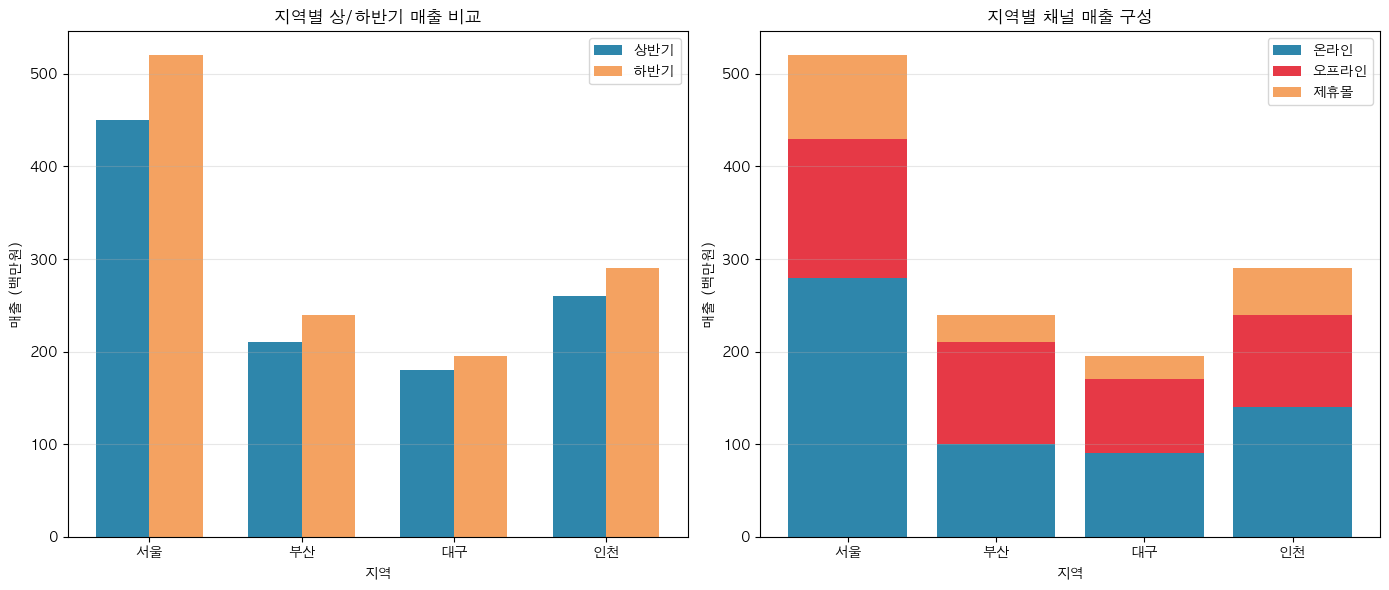

서울: +15.6% growth H1 -> H2
부산: +14.3% growth H1 -> H2
대구: +8.3% growth H1 -> H2
인천: +11.5% growth H1 -> H2


In [ ]:
# Business Example: regional sales growth & channel composition
# 비즈니스 예제: 지역별 매출 성장 & 채널 구성 분석

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# self-contained dataset: H1/H2 sales + channel breakdown by region
# 자체 포함형 데이터셋: 지역별 상/하반기 매출 + 채널 구성
regions = ['서울', '부산', '대구', '인천']
h1_sales = [450, 210, 180, 260]
h2_sales = [520, 240, 195, 290]

channels = ['온라인', '오프라인', '제휴몰']
seoul_channel = [280, 150, 90]
busan_channel = [100, 110, 30]
daegu_channel = [90, 80, 25]
incheon_channel = [140, 100, 50]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (1) grouped bar: H1 vs H2 by region
x = np.arange(len(regions))
width = 0.35
axes[0].bar(x - width / 2, h1_sales, width, label='상반기', color='#2E86AB')
axes[0].bar(x + width / 2, h2_sales, width, label='하반기', color='#F4A261')
axes[0].set_title('지역별 상/하반기 매출 비교')
axes[0].set_xlabel('지역')
axes[0].set_ylabel('매출 (백만원)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(regions)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# (2) 3-tier stacked bar: channel composition by region
channel_data = np.array([seoul_channel, busan_channel, daegu_channel, incheon_channel])
bottom = np.zeros(len(regions))
colors = ['#2E86AB', '#E63946', '#F4A261']
for i, channel in enumerate(channels):
    axes[1].bar(regions, channel_data[:, i], bottom=bottom, label=channel, color=colors[i])
    bottom += channel_data[:, i]   # accumulate the running total / 누적 합계 갱신

axes[1].set_title('지역별 채널 매출 구성')
axes[1].set_xlabel('지역')
axes[1].set_ylabel('매출 (백만원)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

growth = [(h2 - h1) / h1 * 100 for h1, h2 in zip(h1_sales, h2_sales)]
for region, g in zip(regions, growth):
    print(f"{region}: {g:+.1f}% growth H1 -> H2")

---
# 📝 Summary · 요약
*Write today's concept in 3~5 sentences.* · *오늘 배운 개념을 3~5문장으로 정리하세요.*

A Bar Chart compares category sizes using bar length, and it comes in 4 variants: vertical for a handful of short categories, horizontal for long names or 8+ categories, grouped for comparing 2-3 subgroups side by side, and stacked for showing a total together with its composition. Grouped bars work by shifting each subgroup's x-position with `numpy` so `width × number_of_groups` stays under 1, while stacked bars work by passing `bottom=` the running total of everything already drawn beneath the current bar. The most common bugs are bars overlapping from too-wide `width`, layers overlapping from a missing `bottom=`, and a 3rd stacked layer starting at the wrong height because `bottom` used the previous layer's value instead of a running sum. When in doubt about which variant to use, ask whether you're answering "did it change" (grouped) or "how is it composed" (stacked).

Bar Chart는 막대 길이로 카테고리 크기를 비교하며, 4가지 변형이 있습니다: 카테고리가 적고 짧으면 세로, 이름이 길거나 8개 이상이면 가로, 2~3개 하위 그룹을 나란히 비교하려면 그룹, 합계와 구성을 함께 보여주려면 누적을 씁니다. 그룹 막대는 `numpy`로 각 하위 그룹의 x 위치를 이동시켜 `width × 그룹 수`가 1 미만이 되도록 만드는 방식으로 동작하고, 누적 막대는 현재 막대 아래에 이미 그려진 것들의 누적 합계를 `bottom=`으로 넘기는 방식으로 동작합니다. 가장 흔한 버그는 `width`가 너무 넓어 막대가 겹치는 것, `bottom=` 누락으로 레이어가 겹치는 것, 그리고 3번째 누적 레이어가 누적 합계 대신 직전 레이어 값을 써서 엉뚱한 높이에서 시작하는 것입니다. 어떤 변형을 쓸지 헷갈리면, "변했는가"(그룹)를 묻는지 "어떻게 구성되는가"(누적)를 묻는지 자문해보세요.

---
# 📌 One Sentence Summary · 한 줄 요약
Today's topic in ONE sentence. · 오늘의 주제를 한 문장으로.

> A Bar Chart compares categories by bar length, and choosing among its 4 variants (vertical, horizontal, grouped, stacked) comes down to one question: am I comparing separate items, or showing how a total is made up?

> Bar Chart는 막대 길이로 카테고리를 비교하며, 4가지 변형(세로, 가로, 그룹, 누적) 중 무엇을 고를지는 하나의 질문으로 정리된다: 개별 항목을 비교하는가, 아니면 합계가 어떻게 구성되는지 보여주는가?

---
# ❓ Review Questions · 복습 문제

**Q1.** List the 4 Bar Chart variants and, for each, describe the situation where it's the best choice.
Bar Chart의 4가지 변형을 나열하고, 각각 어떤 상황에서 가장 적합한 선택인지 설명하라.

**Q2.** In a grouped bar chart with 2 subgroups, why must `width` stay at 0.4 or below, and what happens if it doesn't?
2개의 하위 그룹을 가진 그룹 막대 차트에서 `width`가 왜 0.4 이하여야 하며, 그렇지 않으면 어떤 일이 생기는가?

**Q3.** When stacking 3 categories, what value should `bottom` hold for the 3rd bar, and why is using only the 2nd layer's value wrong?
3개 카테고리를 누적할 때, 3번째 막대의 `bottom`은 어떤 값을 가져야 하며, 2번째 레이어 값만 쓰는 것이 왜 잘못되었는가?

**Q4.** A colleague has 12 country names to compare and keeps fighting with overlapping x-axis labels. What would you suggest, and why?
동료가 12개 국가명을 비교해야 하는데 x축 라벨이 계속 겹친다고 한다. 무엇을 제안하겠으며, 그 이유는 무엇인가?

**Q5.** You need to show both "did total sales grow this year" and "which channel drove that total." Which Bar Chart variant(s) would you use, and how would you lay them out?
"올해 총매출이 성장했는가"와 "어느 채널이 그 합계를 이끌었는가"를 둘 다 보여줘야 한다. 어떤 Bar Chart 변형을 쓰겠으며, 어떻게 배치하겠는가?

---
*📅 Try answering these again in a few days.* · *📅 며칠 후에 다시 답해보세요.*